In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("arjunbhasin2013/ccdata")

# print("Path to dataset files:", path)

## Подключаем нужные библиотеки

In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, LabelEncoder, OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

## Загружаем датасет и проводим EDA

In [3]:
df = pd.read_csv('CC_GENERAL.csv', index_col='CUST_ID')
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 8950 entries, C10001 to C19190
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT_LIMIT   

Вероятно, это данные по кредитным картам клиентов:

1. `BALANCE` -- остаток на счёте (сумма долга на конец периода)
2. `BALANCE_FREQUENCY` -- частота обновления остатка (как часто менялся баланс, от 0 до 1)
3. `PURCHASES` -- сумма покупок (всего потрачено через карту)
4. `ONEOFF_PURCHASES` -- сумма разовых покупок (не в рассрочку/кредит)
5. `INSTALLMENTS_PURCHASES` -- сумма покупок в рассрочку (частями)
6. `CASH_ADVANCE` -- сумма снятых наличных (кэш-аванс)
7. `PURCHASES_FREQUENCY` -- частота совершения покупок (доля месяцев с покупками)
8. `ONEOFF_PURCHASES_FREQUENCY` -- частота разовых покупок
9. `PURCHASES_INSTALLMENTS_FREQUENCY` -- частота покупок в рассрочку
10. `CASH_ADVANCE_FREQUENCY` -- частота снятия наличных
11. `CASH_ADVANCE_TRX` -- количество транзакций снятия наличных
12. `PURCHASES_TRX` -- количество покупок (транзакций)
13. `CREDIT_LIMIT` -- кредитный лимит по карте
14. `PAYMENTS` -- сумма платежей (сколько клиент заплатил в погашение долга)
15. `MINIMUM_PAYMENTS` -- сумма минимальных обязательных платежей
16. `PRC_FULL_PAYMENT` -- доля месяцев, когда долг выплачивался полностью (процент)
17. `TENURE` -- срок использования карты (в месяцах, сколько месяцев клиент с картой)

Эти признаки обычно используют для прогнозирования дефолта или анализа поведения держателей кредитных карт.

Есть несколько пропусков у `CREDIT_LIMIT` (1) и `MINIMUM_PAYMENTS` (313)

Заполним NULL-значения в `MINIMUM_PAYMENTS` нулями.

А `CREDIT_LIMIT` заполним медианным значением.

In [5]:
df['MINIMUM_PAYMENTS'] = 0

df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 8950 entries, C10001 to C19190
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT_LIMIT   

In [7]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.0,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,0.0,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,0.0,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.0,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,0.0,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,0.0,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,0.0,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,0.0,1.000000,12.000000


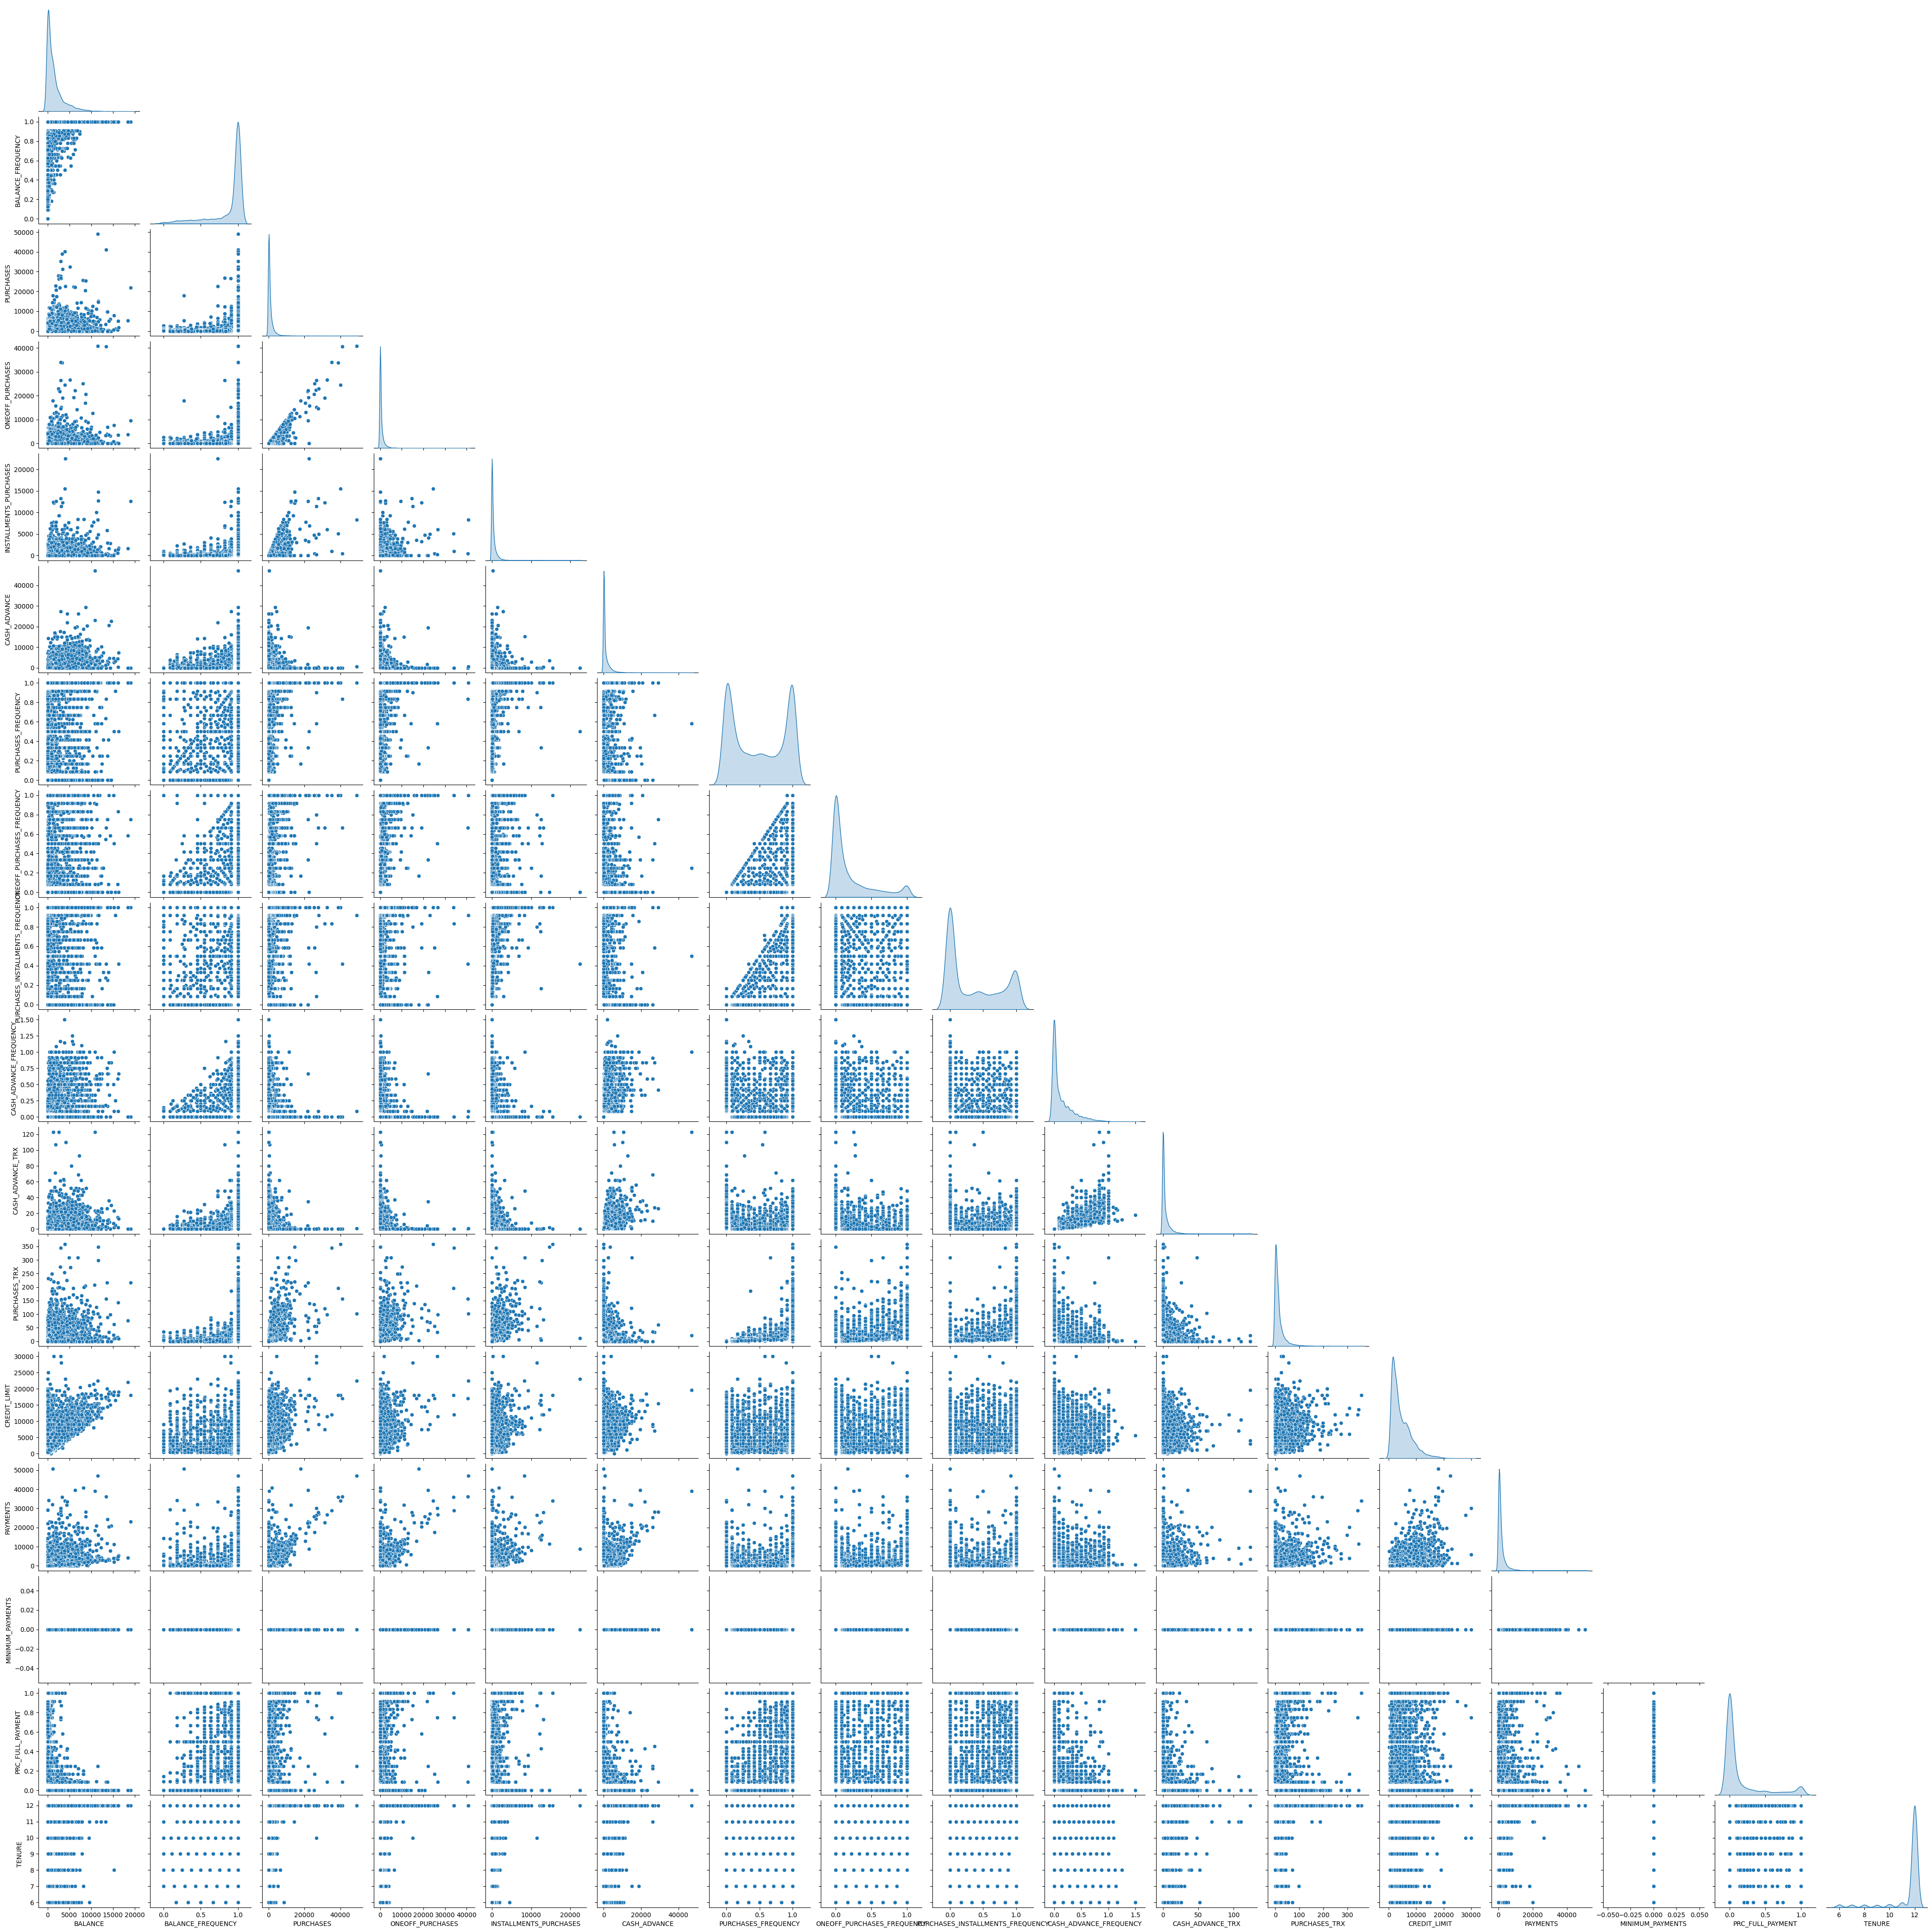

In [8]:
sns.pairplot(
    df,
    diag_kind='kde',
    corner=True
    )
plt.show()

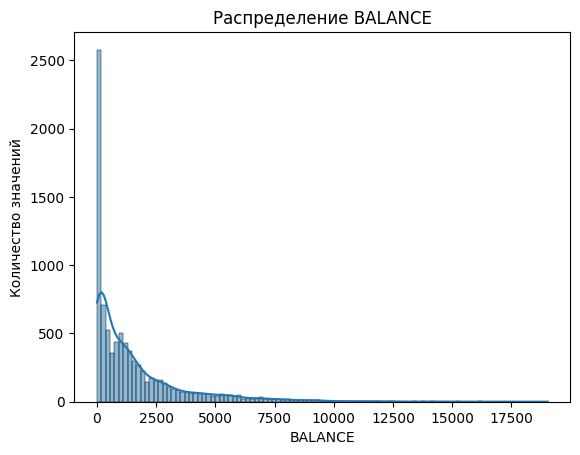

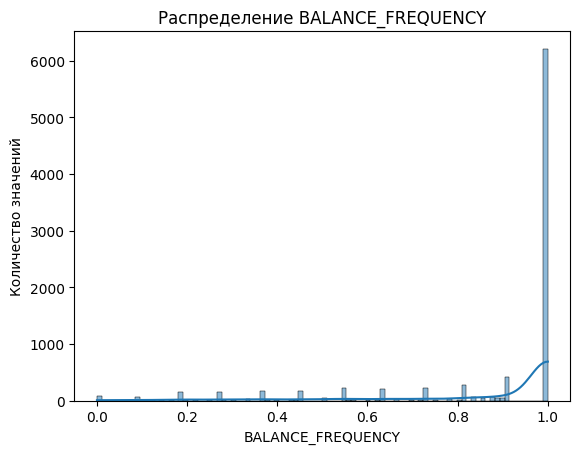

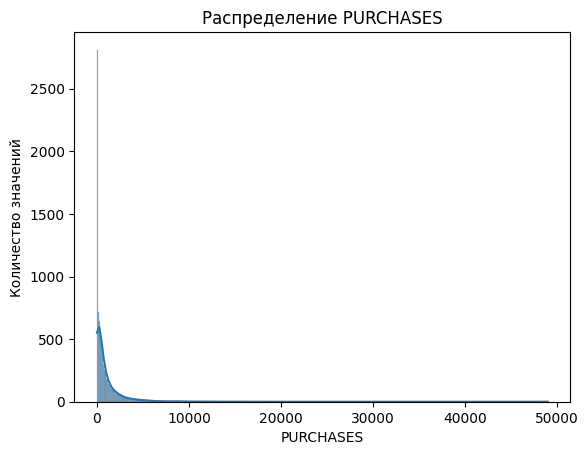

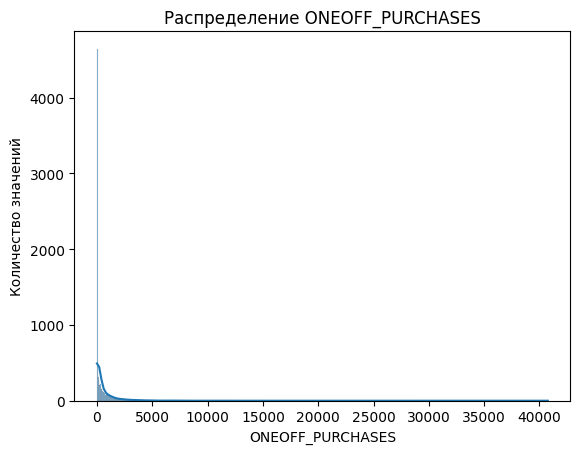

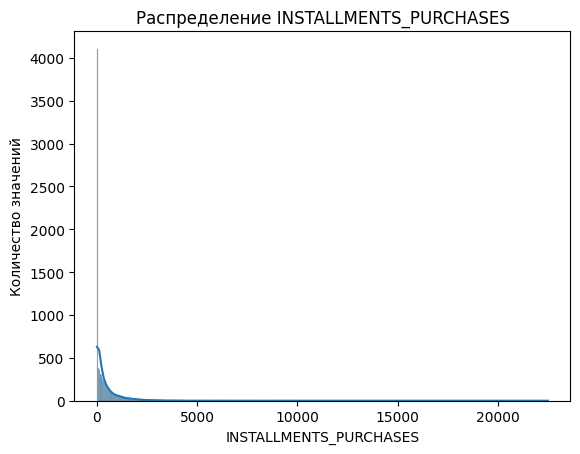

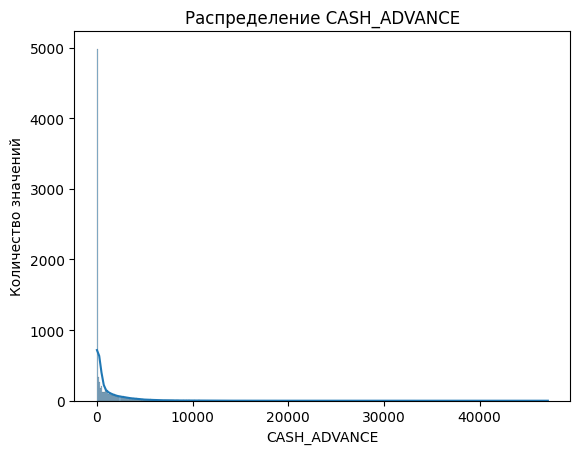

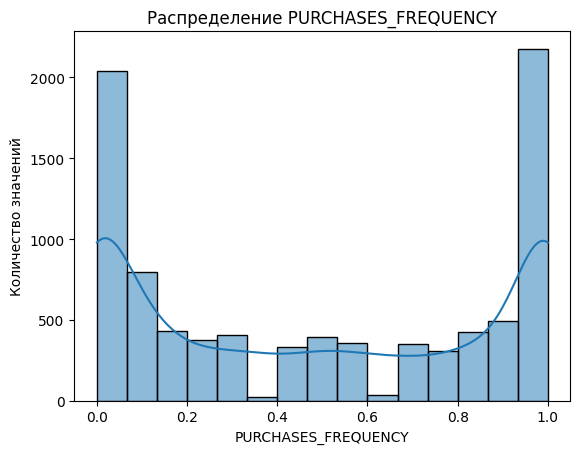

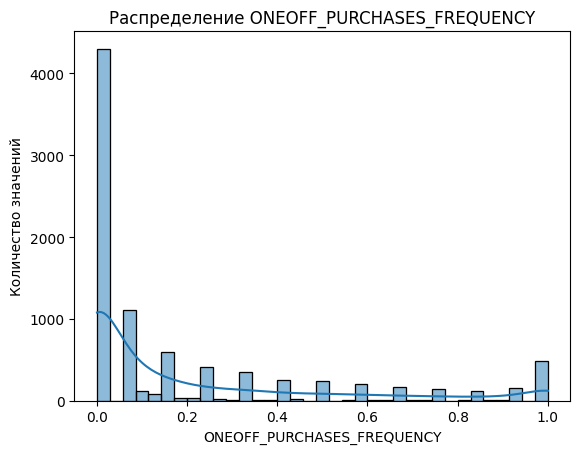

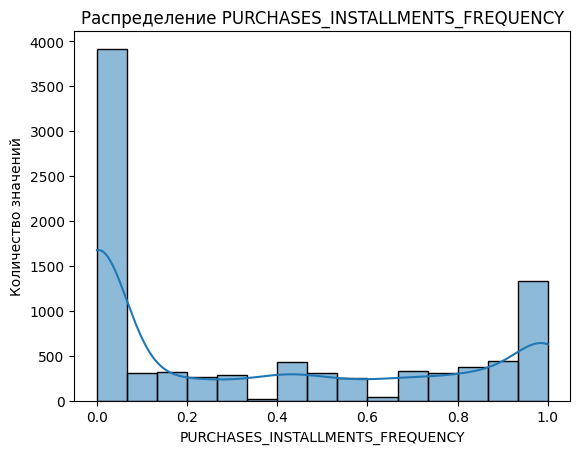

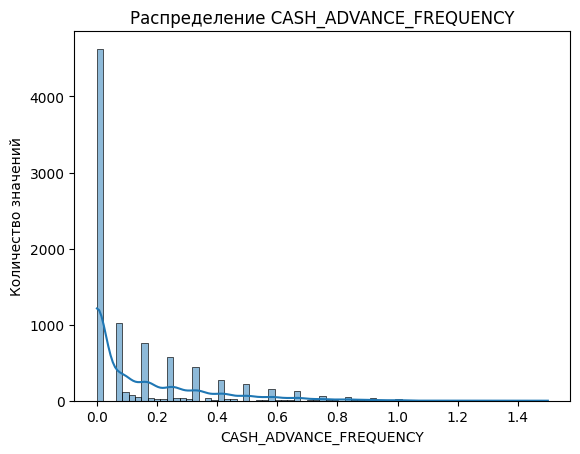

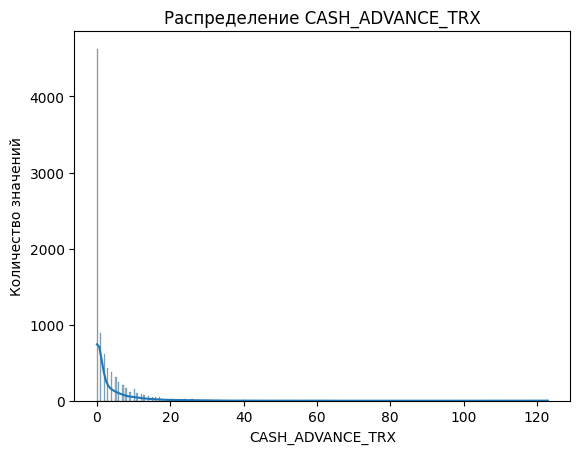

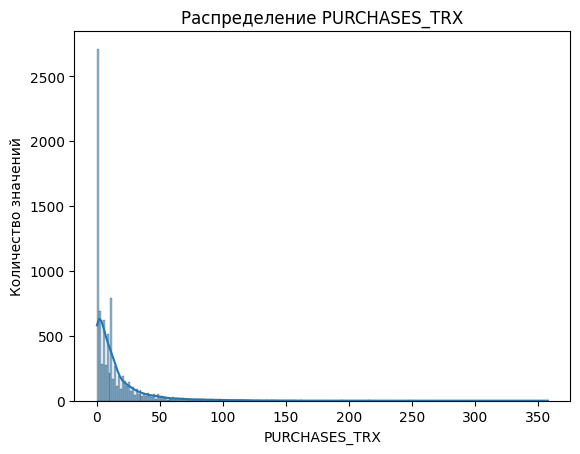

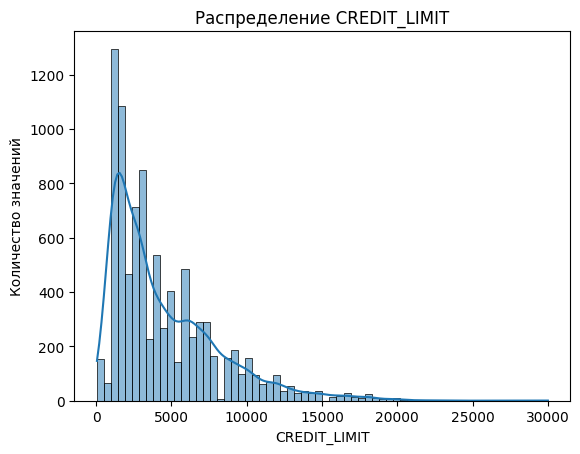

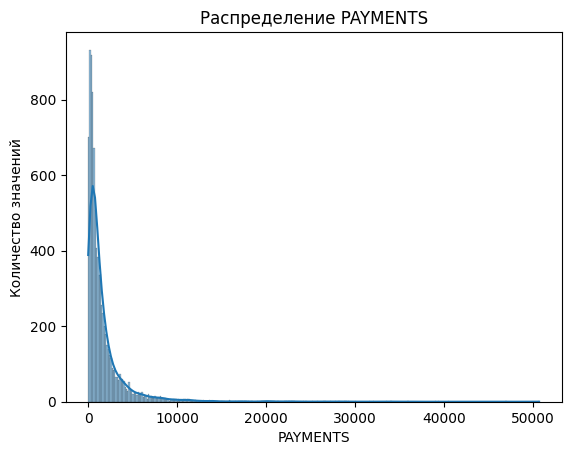

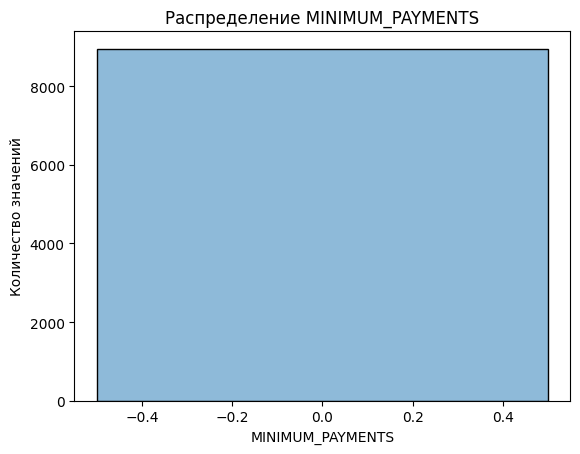

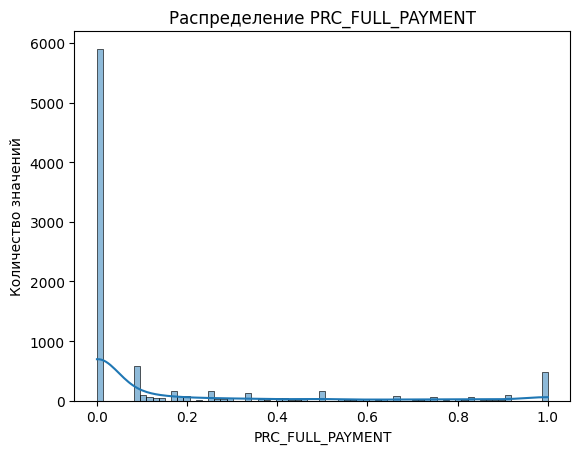

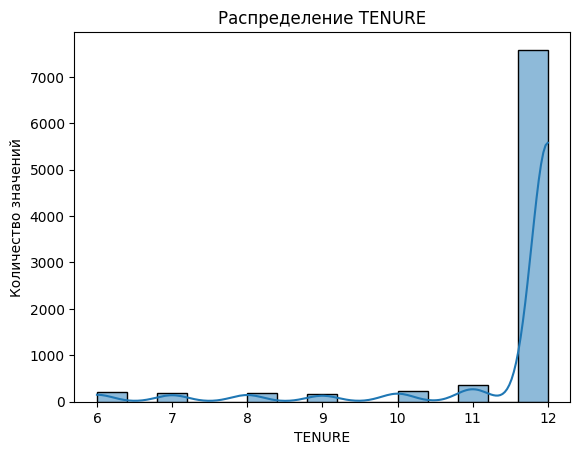

In [9]:
for col in df.columns:
    plt.figure()
    sns.histplot(data=df, x=col, stat='count', kde=True)
    plt.title(f'Распределение {col}')
    plt.ylabel('Количество значений')
    plt.show()

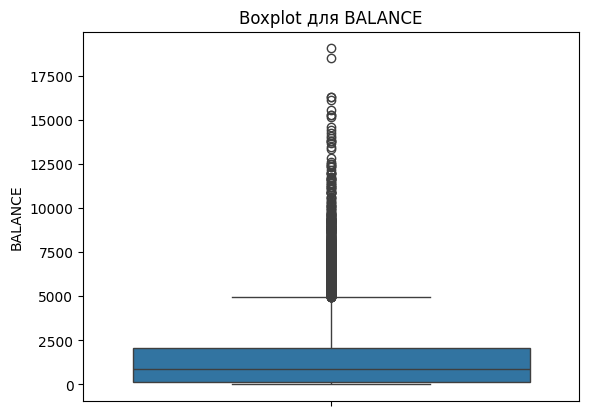

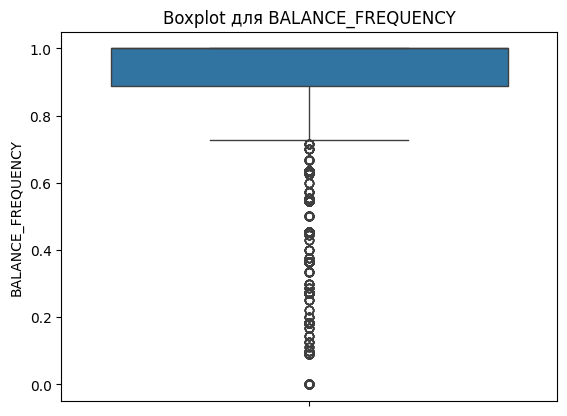

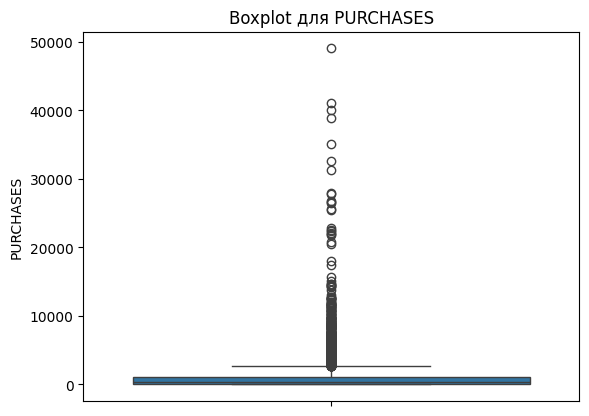

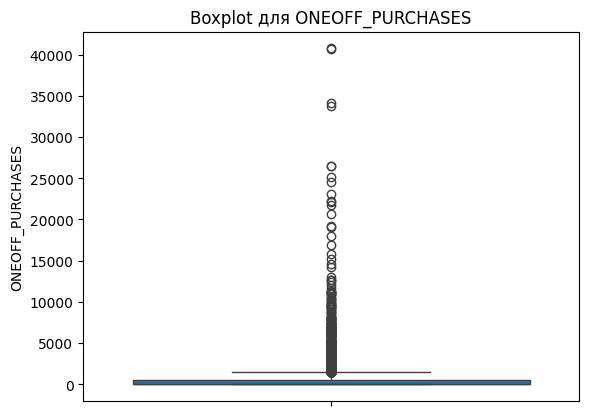

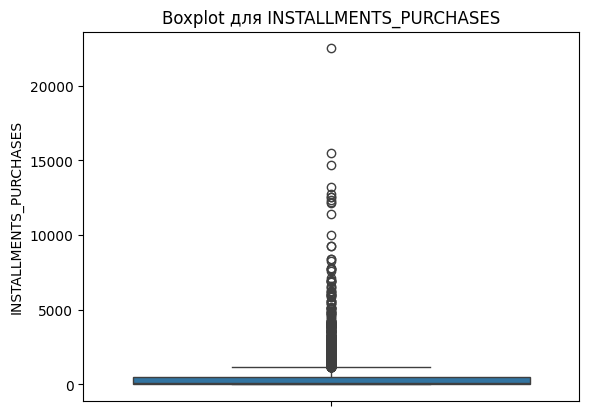

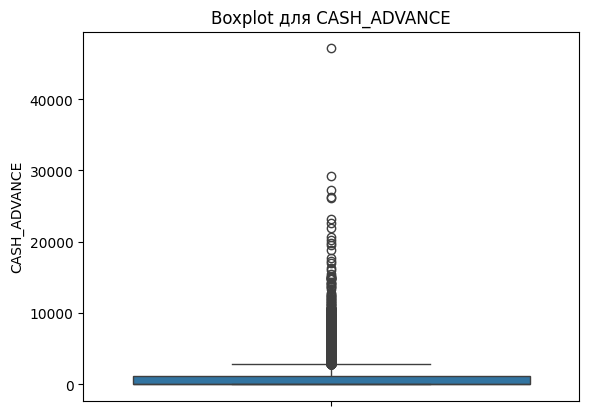

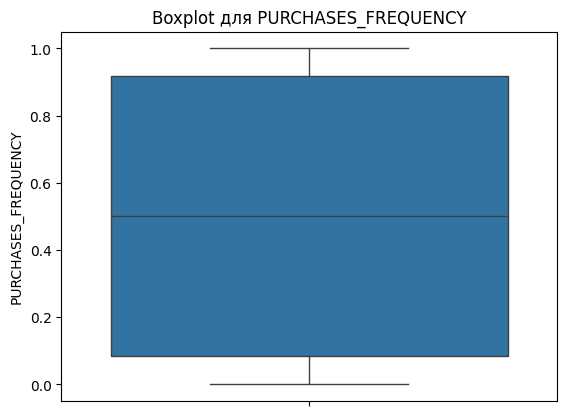

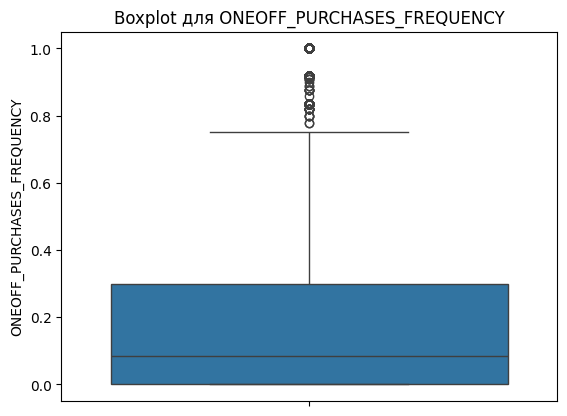

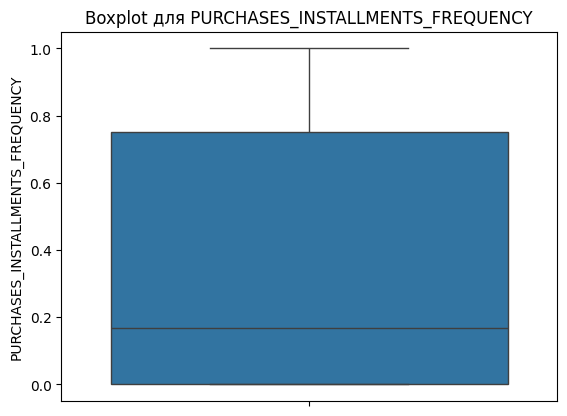

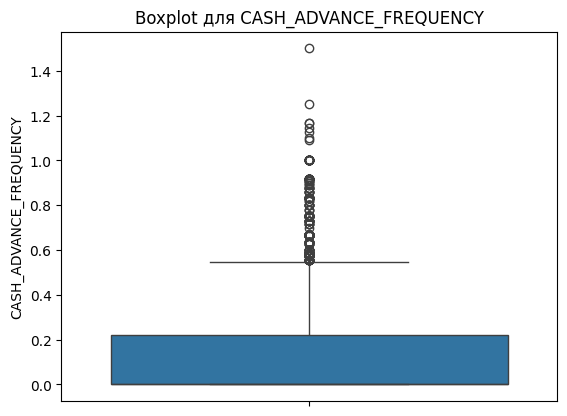

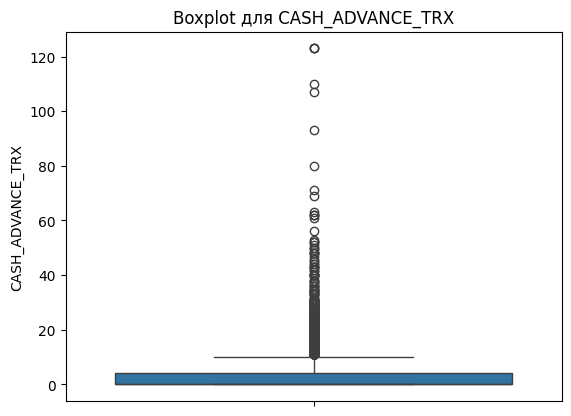

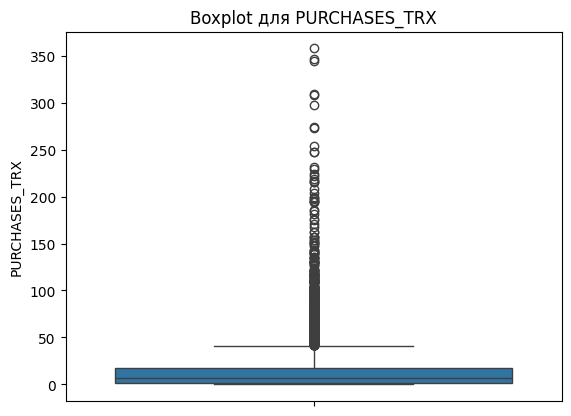

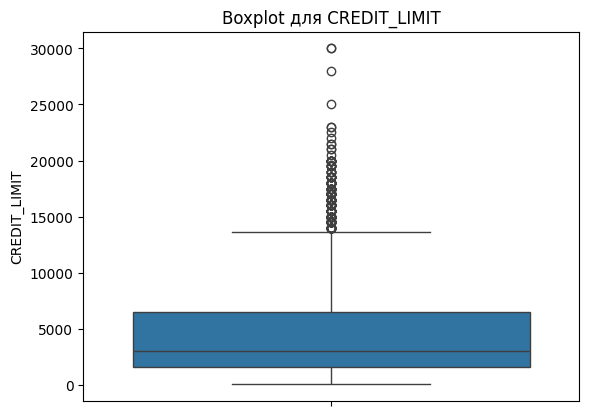

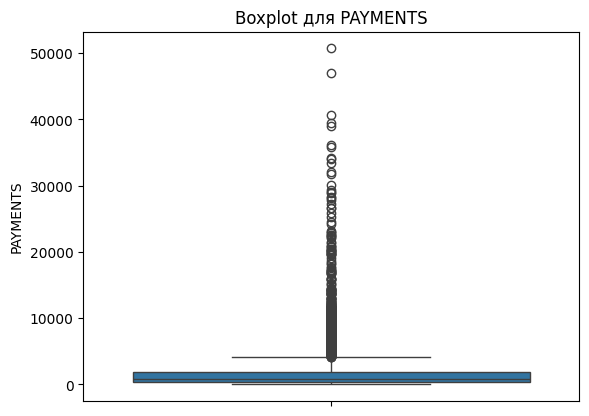

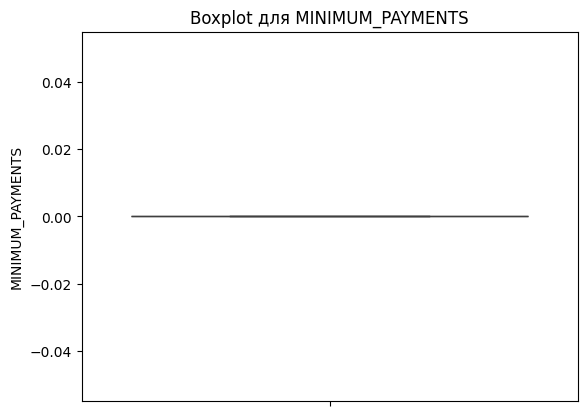

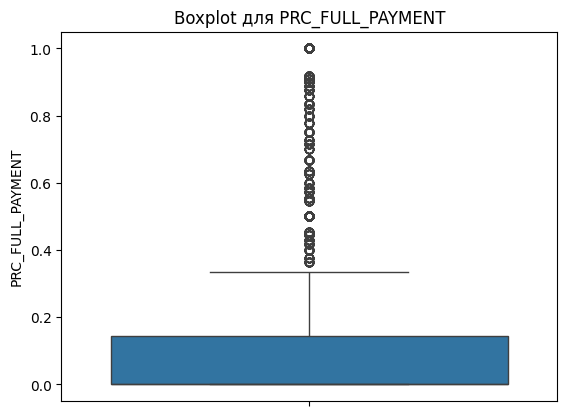

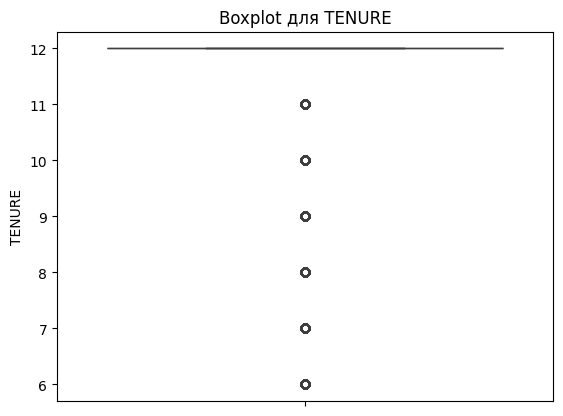

In [10]:
for col in df.columns:
    plt.figure()
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot для {col}')
    plt.ylabel(col)
    plt.show()

Вывод: в данных очень много различных выбросов, но возможно (если, например, будем искать фрод) это важно.

Для начала просто попробуем скалировать признаки и применить DBSCAN, который хорошо обрабатывает выбросы, помечая их

In [11]:
st_scaler = StandardScaler()
for col in df.columns:
    df[col] = st_scaler.fit_transform(df[[col]])

In [12]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,0.0,-0.525551,0.36068
C10002,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.0,0.234227,0.36068
C10003,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,0.0,-0.525551,0.36068
C10004,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,0.0,-0.525551,0.36068
C10005,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,0.0,-0.525551,0.36068


In [13]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

def evaluate_dbscan_params(X_scaled, eps, min_samples):
    """Оценка параметров по понятным критериям"""
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = sum(labels == -1)
    noise_ratio = n_noise / len(labels) * 100
    
    # Размеры кластеров
    cluster_sizes = []
    for label in set(labels):
        if label != -1:
            size = sum(labels == label)
            cluster_sizes.append(size)
    
    min_cluster_size = min(cluster_sizes) if cluster_sizes else 0
    max_cluster_size = max(cluster_sizes) if cluster_sizes else 0
    
    return {
        'n_clusters': n_clusters,
        'noise_ratio': noise_ratio,
        'min_cluster_size': min_cluster_size,
        'max_cluster_size': max_cluster_size,
        'cluster_sizes': cluster_sizes
    }

eps_start = 0.1
eps_end = 2.5
eps_step = 0.05

min_samples_start = 10
min_samples_end = 20 

# Создаем список eps значений
eps_values = [round(eps_start + i * eps_step, 2) for i in range(int((eps_end - eps_start) / eps_step) + 1)]

print(f"eps значения: от {eps_start} до {eps_end} с шагом {eps_step}")
print(f"Всего eps: {len(eps_values)}")
print(f"min_samples: от {min_samples_start} до {min_samples_end}")
print(f"Всего комбинаций: {len(eps_values) * (min_samples_end - min_samples_start + 1)}")

# Перебор параметров
results_data = []

for eps in tqdm(eps_values, desc="Перебор eps"):
    for min_samples in range(min_samples_start, min_samples_end + 1):
        stats = evaluate_dbscan_params(df, eps, min_samples)
        results_data.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': stats['n_clusters'],
            'noise_ratio': round(stats['noise_ratio'], 2),
            'min_cluster_size': stats['min_cluster_size'],
            'max_cluster_size': stats['max_cluster_size']
        })

# Создаем DataFrame
params_df = pd.DataFrame(results_data)

eps значения: от 0.1 до 2.5 с шагом 0.05
Всего eps: 48
min_samples: от 10 до 20
Всего комбинаций: 528


Перебор eps: 100%|██████████| 48/48 [00:34<00:00,  1.40it/s]


Смотрим "золотую середину": кластеры больше 3 и шум 45-55%

In [14]:
params_df[(params_df['n_clusters'] > 3) & (params_df['noise_ratio'] <= 55) & (params_df['noise_ratio'] >= 45)]

,eps,min_samples,n_clusters,noise_ratio,min_cluster_size,max_cluster_size
154,0.80,10,8,53.05,5,4109
155,0.80,11,6,53.91,6,4005
156,0.80,12,7,54.55,5,3945
165,0.85,10,8,49.34,5,4457
166,0.85,11,5,50.21,10,4398
167,0.85,12,5,50.93,15,4255
168,0.85,13,5,51.69,14,4201
169,0.85,14,6,52.09,9,4156
170,0.85,15,4,52.96,16,4113
171,0.85,16,5,53.40,16,4054


Попробуем значение `eps = 0.9` и `min_samples = 12`

In [15]:
dbscan = DBSCAN(eps=0.9, min_samples=12)

df_dbscan = dbscan.fit_predict(df)

In [16]:
df_dbscan

array([ 0, -1,  0, ..., -1, -1, -1], dtype=int64)

In [17]:
df['CLUSTER'] = df_dbscan

In [18]:
df['CLUSTER'].unique()

array([ 0, -1,  1,  3,  4,  2], dtype=int64)

Получилось 4 кластера (от `0` до `3`) + выбросы (кластер `-1`)

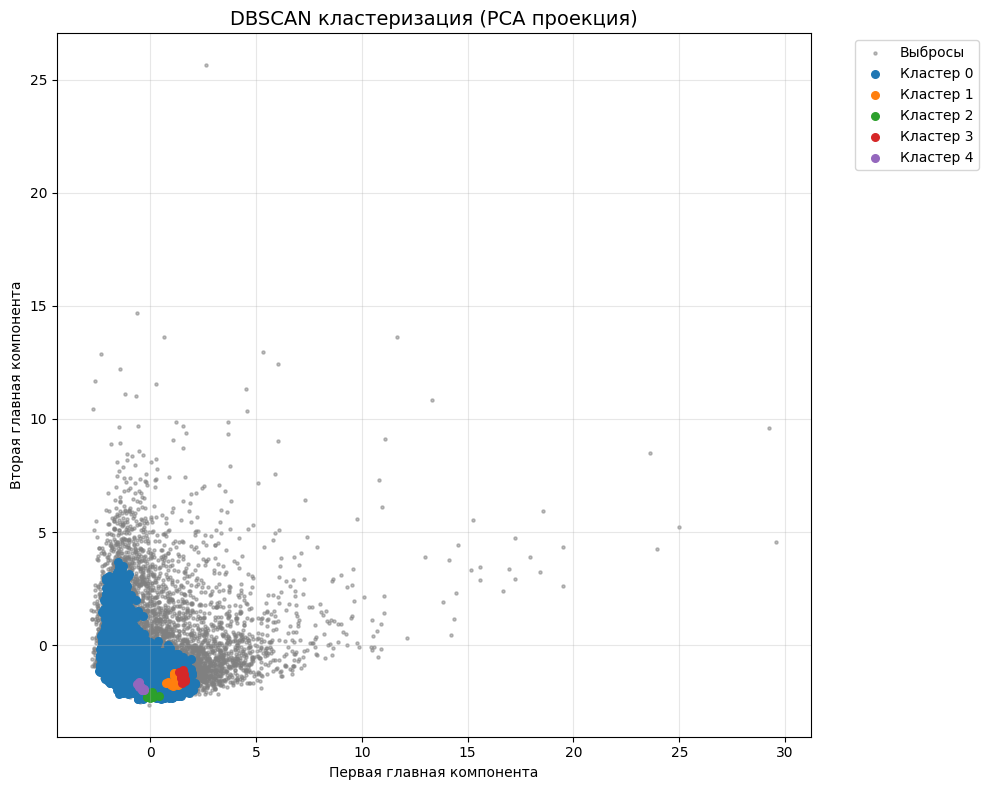

In [19]:
# Проецируем на 2 главных компоненты
pca = PCA(n_components=2)
X_2d = pca.fit_transform(df.drop('CLUSTER', axis=1))

# Визуализация
plt.figure(figsize=(10, 8))

# Для каждого кластера рисуем свой цвет
labels = df['CLUSTER']
unique_labels = np.unique(labels)
for label in unique_labels:
    if label == -1:
        # Выбросы: серые точки, маленькие, полупрозрачные
        plt.scatter(X_2d[labels == label, 0], 
                   X_2d[labels == label, 1],
                   c='gray', marker='.', s=20, alpha=0.5, label='Выбросы')
    else:
        # Кластеры: яркие цвета, крупнее
        plt.scatter(X_2d[labels == label, 0],
                   X_2d[labels == label, 1],
                   marker='o', s=30, label=f'Кластер {label}')

plt.title('DBSCAN кластеризация (PCA проекция)', fontsize=14)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# PCA
pca = PCA(n_components=3)
X_3d = pca.fit_transform(df.drop('CLUSTER', axis=1))

labels = df['CLUSTER'].values
unique_labels = np.unique(labels)

# ЯВНО задаем цвета (те же, что обычно использует matplotlib tab10)
# Это стандартные цвета tab10 в HEX
tab10_colors = [
    '#1f77b4',  # синий (кластер 0)
    '#ff7f0e',  # оранжевый (кластер 1)
    '#2ca02c',  # зеленый (кластер 2)
    '#d62728',  # красный (кластер 3)
    '#9467bd',  # фиолетовый (кластер 4)
    '#8c564b',  # коричневый (кластер 5)
    '#e377c2',  # розовый (кластер 6)
    '#7f7f7f',  # серый (кластер 7)
    '#bcbd22',  # оливковый (кластер 8)
    '#17becf'   # голубой (кластер 9)
]

# Создаем словарь цветов
color_map = {-1: 'lightgray'}  # выбросы - светло-серый
for i, label in enumerate([l for l in unique_labels if l != -1]):
    if i < len(tab10_colors):
        color_map[label] = tab10_colors[i]
    else:
        # Если кластеров больше 10, берем цвета из другого набора
        color_map[label] = plt.cm.tab20(i/20)

# Визуализация
fig = go.Figure()

for label in unique_labels:
    mask = labels == label
    name = 'Выбросы' if label == -1 else f'Кластер {label}'
    
    fig.add_trace(go.Scatter3d(
        x=X_3d[mask, 0],
        y=X_3d[mask, 1],
        z=X_3d[mask, 2],
        mode='markers',
        marker=dict(
            size=3 if label == -1 else 4,
            color=color_map[label],
            opacity=0.4 if label == -1 else 0.8
        ),
        name=name
    ))

fig.update_layout(
    title='DBSCAN кластеризация (3D PCA)',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2', 
        zaxis_title='PC3'
    ),
    legend_title_text='Кластеры',
    width=1000,
    height=800
)

fig.show()

Silhouette Score: 0.341


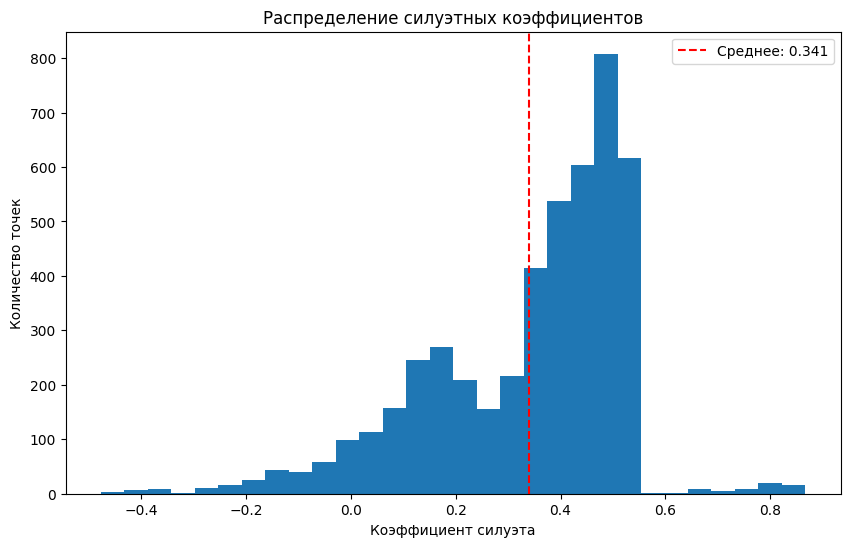

In [21]:
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt

# Только для точек, не являющихся выбросами
mask = labels != -1
if len(set(labels[mask])) > 1:
    sil_score = silhouette_score(df[mask], labels[mask])
    print(f"Silhouette Score: {sil_score:.3f}")
    # Интерпретация:
    # > 0.5 - хорошая кластеризация
    # 0.2-0.5 - средняя
    # < 0.2 - плохая (кластеры пересекаются)
    
    # График силуэтов
    sil_vals = silhouette_samples(df[mask], labels[mask])
    plt.figure(figsize=(10, 6))
    plt.hist(sil_vals, bins=30)
    plt.axvline(x=sil_score, color='r', linestyle='--', label=f'Среднее: {sil_score:.3f}')
    plt.xlabel('Коэффициент силуэта')
    plt.ylabel('Количество точек')
    plt.title('Распределение силуэтных коэффициентов')
    plt.legend()
    plt.show()

In [22]:
from sklearn.metrics import calinski_harabasz_score

if len(set(labels[mask])) > 1:
    ch_score = calinski_harabasz_score(df[mask], labels[mask])
    print(f"Calinski-Harabasz Index: {ch_score:.2f}")
    # Чем выше, тем лучше (кластеры плотные и разделенные)

Calinski-Harabasz Index: 71.63


`Silhouette Score = 0.391` говорит, что кластеры хорошо различимы, но не идеальны.

`Calinski-Harabasz Index = 80.91` говорит, что это отличное разделение

Высокий уровень шума (49%) - много выбросов

Сильный дисбаланс кластеров (от 12 до 4479 точек)

Один гигантский кластер + несколько мелких

Качество кластеризации удовлетворительное для реальных данных. Параметры принимаются — они обеспечивают баланс между выделением структуры и выявлением аномалий.

Выбранные параметры (`eps=0.9`, `min_samples=12`) принимаются как рабочие, поскольку они позволяют выделить содержательную структуру из `4` кластеров и идентифицировать аномалии. Дальнейшее улучшение метрик приведёт к потере мелких кластеров и слиянию групп, что снизит практическую ценность результата.